<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/ML_AI25_HT7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание 7: Fraud Detection Competition**

Добро пожаловать на финальное домашнее задание курса! Домашнее задание направлено на систематизацию всех знаний, полученных в процессе учебы.

В нём Вы потренируетесь применять навыки построения пайплайнов машинного обучения, приобретенные в курсе. Цель — пройти от точки разведочного анализа данных до построения и валидации моделей машинного обучения самостоятельно. Мы верим в вас!

## **Задача**
**Вы будете решать задачу определения фрода:**

https://www.kaggle.com/competitions/ai-masters-fraud-detection/overview

**Вам нужно будет:**
- в jupyter notebook провести исследование данных;
- в нём же построить модели и оценить их качество;
- отправить посылку на Kaggle.

Более подробное описание шагов - в ноутбуке ниже.

## **Оценивание и баллы**
- В EDA и во всей работе будут оцениваться полнота и **выводы**;
- При обучении моделей старайтесь обоснованно подходить к их выбору, избегая простого перебора;

**Максимальный балл** - 10 (+ бонусы за Kaggle, см. ниже).


Мягкий дедлайн (окончание соревнования на Kaggle): **17 марта 23:59**


In [3]:
!pip install catboost

In [26]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import IsolationForest

from catboost import CatBoostClassifier

# **Базовое решение и пример формирования файла под submission**


In [2]:
!wget --no-check-certificate 'https://www.dropbox.com/s/5iuef7c9ljj84t6/train_transaction.csv?dl=0' -O train_transaction.csv
!wget --no-check-certificate 'https://www.dropbox.com/s/cmy01z5fw7ohlmd/train_identity.csv?dl=0' -O train_identity.csv
!wget --no-check-certificate 'https://www.dropbox.com/s/7thqkuxnwsa7njj/test_transaction.csv?dl=0' -O test_transaction.csv
!wget --no-check-certificate 'https://www.dropbox.com/s/b40nvbb9e2usd5w/test_identity.csv?dl=0' -O test_identity.csv
!wget --no-check-certificate 'https://www.dropbox.com/s/arkyoz0bel8z4d2/sample_submission.csv?dl=0' -O sample_submission.csv

--2026-03-20 14:25:04--  https://www.dropbox.com/s/5iuef7c9ljj84t6/train_transaction.csv?dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.6.18, 2620:100:601c:18::a27d:612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.6.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/puoen4suxjebjteenuwtm/train_transaction.csv?rlkey=madfflananln1b7qysdq8c54q&dl=0 [following]
--2026-03-20 14:25:04--  https://www.dropbox.com/scl/fi/puoen4suxjebjteenuwtm/train_transaction.csv?rlkey=madfflananln1b7qysdq8c54q&dl=0
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘train_transaction.csv’

train_transaction.c     [<=>                 ]       0  --.-KB/s               ^C
--2026-03-20 14:25:05--  https://www.dropbox.com/s/cmy01z5fw7ohlmd/train_identity.csv?dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.6.18, 2620:100:601c:18

In [3]:
!pip install catboost -q

In [5]:
from catboost import CatBoostClassifier
import pandas as pd
import os
from tqdm import tqdm

INPUT_DIR = '.'

train_transaction = pd.read_csv(os.path.join(INPUT_DIR, 'train_transaction.csv'))
train_identity = pd.read_csv(os.path.join(INPUT_DIR, 'train_identity.csv'))
test_transaction = pd.read_csv(os.path.join(INPUT_DIR, 'test_transaction.csv'))
test_identity = pd.read_csv(os.path.join(INPUT_DIR, 'test_identity.csv'))
sample_submission = pd.read_csv(os.path.join(INPUT_DIR, 'sample_submission.csv'))

df_train = train_transaction.merge(train_identity, how='left', on='TransactionID')

df_test = test_transaction.merge(test_identity, how='left', on='TransactionID')

In [6]:
df_train.drop(['TransactionID', 'TransactionDT'], axis=1, inplace=True)
df_test.drop(['TransactionID', 'TransactionDT'], axis=1, inplace=True)
df_train.shape, df_test.shape

((417559, 432), (172981, 431))

In [7]:
object_cols = []
for idx, col in tqdm(enumerate(df_train.columns.drop('isFraud'))):
    if df_train[col].dtype == 'O':
      object_cols.append(idx)

431it [00:00, 28306.17it/s]


In [8]:
X_train = df_train.drop('isFraud', axis=1)
X_train = X_train.fillna('')
y_train = df_train['isFraud'].values

cb = CatBoostClassifier(iterations=3)
cb.fit(X_train, y_train, object_cols, )

Learning rate set to 0.5
0:	learn: 0.2082395	total: 1.65s	remaining: 3.3s
1:	learn: 0.1360790	total: 2.92s	remaining: 1.46s
2:	learn: 0.1180984	total: 4.82s	remaining: 0us


CatBoostClassifier(iterations=3)

In [9]:
predictions = cb.predict_proba(df_test.fillna(''))

In [10]:
sub = pd.DataFrame({'TransactionID': sample_submission['TransactionID'], 'isFraud': predictions[:, 0]})
sub.head()

,TransactionID,isFraud
0,3404559,0.978714
1,3404560,0.935724
2,3404561,0.946864
3,3404562,0.978714
4,3404563,0.970637


In [12]:
# Сохранение submission
sub.to_csv('submission_baseline.csv', index=False)

### **Примечания:**

**1. Оценка качества и Submission File**
- Ответом является число от 0 до 1, метрикой качества - AUC-ROC.
- Структура Submission File:
 - для каждого значения *TransactionID* в тестовых данных вы должны предсказать **вероятность** для столбца *isFraud*.
 - в файле у вас должно быть две колонки: `TransactionID` и`isFraud`  **для каждой транзакции в датасете**.

**2. Объем данных**

Поскольку набор данных объемный, могут быть проблемы с переполнением памяти в Collab. Для решения проблемы можете использовать функцию из [этого ноутбука](https://colab.research.google.com/drive/18u75eyFGEoyeWJ_MbsLkcPa6gv2tNI8G#scrollTo=V2L1Nl5CTMMl), разобравшись, что она делает с данными.

# **Задание 1 (2 балла)**

Проведите EDA (разведочный анализ данных):
* проанализируйте признаки, их особенности и связь с целевой переменной
* проанализируйте целевую переменную
* оцените степень попарной взаимосвязи признаков, а также связи признаков и целевой переменной
* по результатам исследований сделайте необходимую обработку данных (удаление дублей, работа с пропусками, с категориальными столбцами (если они есть), работа с аномалиями, другие преобразования признаков)

Важно, что EDA всегда сопровождается выводами - не забудьте об этом.

### **За что могут быть снижены баллы:**

1. Вы приводите графики и не подкрепляете их выводами.
2. Оформление анализа данных в ноутбуке нечитаемое — лишние выводы, warnings, слишком большие графики.
3. Выбранные преобразования признаков не обоснованы текстом.
4. Нет summary по всем исследованным признакам и зависимостям.

In [4]:
def reduce_mem_usage(df):
    NAlist = [] # Keeps track of columns that have missing values filled in.
    for col in tqdm(df.columns):
        if df[col].dtype != object:  # Exclude strings

            # make variables for Int, max and min
            IsInt = False
            col_max_value = df[col].max()
            col_min_value = df[col].min()

            # Integer does not support NA, therefore, NA needs to be filled
            if not np.isfinite(df[col]).all():
                NAlist.append(col)
                df[col].fillna(col_min_value - 1, inplace=True)

            # test if column can be converted to an integer
            col_as_int = df[col].fillna(0).astype(np.int64)
            diff = (df[col] - col_as_int)
            diff = diff.sum()
            if np.abs(diff) < 0.01:
                IsInt = True

            # Make Integer/unsigned Integer datatypes
            if IsInt:
                if col_min_value >= 0:
                    if col_max_value < 255:
                        df[col] = df[col].astype(np.uint8)
                    elif col_max_value < 65535:
                        df[col] = df[col].astype(np.uint16)
                    elif col_max_value < 4294967295:
                        df[col] = df[col].astype(np.uint32)
                    else:
                        df[col] = df[col].astype(np.uint64)
                else:
                    if col_min_value > np.iinfo(np.int8).min and col_max_value < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif col_min_value > np.iinfo(np.int16).min and col_max_value < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    elif col_min_value > np.iinfo(np.int32).min and col_max_value < np.iinfo(np.int32).max:
                        df[col] = df[col].astype(np.int32)
                    elif col_min_value > np.iinfo(np.int64).min and col_max_value < np.iinfo(np.int64).max:
                        df[col] = df[col].astype(np.int64)

            # Make float datatypes 32 bit
            else:
                df[col] = df[col].astype(np.float32)

    return df, NAlist

In [5]:
INPUT_DIR = '.'

train_transaction = pd.read_csv(os.path.join(INPUT_DIR, 'train_transaction.csv'))
train_identity = pd.read_csv(os.path.join(INPUT_DIR, 'train_identity.csv'))
test_transaction = pd.read_csv(os.path.join(INPUT_DIR, 'test_transaction.csv'))
test_identity = pd.read_csv(os.path.join(INPUT_DIR, 'test_identity.csv'))

df_train = train_transaction.merge(train_identity, how='left', on='TransactionID')
del train_transaction, train_identity

df_test = test_transaction.merge(test_identity, how='left', on='TransactionID')
del test_transaction, test_identity

df_train_NAlist = df_train.columns[df_train.isna().any()].tolist()
df_test_NAlist = df_test.columns[df_test.isna().any()].tolist()

for col in df_train.columns:
    if df_train[col].dtype != object and df_train[col].isna().any():
        col_min = df_train[col].min()
        fill_value = 0 if pd.isna(col_min) or col_min >= 0 else col_min - 1
        df_train[col] = df_train[col].fillna(fill_value)

for col in df_test.columns:
    if df_test[col].dtype != object and df_test[col].isna().any():
        col_min = df_test[col].min()
        fill_value = 0 if pd.isna(col_min) or col_min >= 0 else col_min - 1
        df_test[col] = df_test[col].fillna(fill_value)

df_train, _ = reduce_mem_usage(df_train)
df_test, _ = reduce_mem_usage(df_test)

100%|██████████| 433/433 [00:01<00:00, 280.04it/s]


In [6]:
print('Missing data in train: {:.5f}%'.format(df_train.isnull().sum().sum() / (df_train.shape[0] * df_train.shape[1]) * 100))
print('Missing data in test: {:.5f}%'.format(df_test.isnull().sum().sum() / (df_test.shape[0] * df_test.shape[1]) * 100))

Missing data in train: 4.47002%
Missing data in test: 4.33051%


In [7]:
df_train.drop(['TransactionID', 'TransactionDT'], axis=1, inplace=True)
df_test.drop(['TransactionID', 'TransactionDT'], axis=1, inplace=True)
df_train.shape, df_test.shape

((417559, 432), (172981, 431))

In [8]:
print('Train shape:', df_train.shape)
print('Test shape:', df_test.shape)

print('\nTarget distribution:')
print(df_train['isFraud'].value_counts(dropna=False))
print(df_train['isFraud'].value_counts(normalize=True, dropna=False))

print('\nDtypes summary:')
print(df_train.dtypes.value_counts())

print('\nDuplicates in train:', df_train.duplicated().sum())
print('Duplicates in test:', df_test.duplicated().sum())

missing_share_train = df_train.isna().mean().sort_values(ascending=False)
missing_share_test = df_test.isna().mean().sort_values(ascending=False)

print('\nTop-20 missing columns in train:')
print(missing_share_train.head(20))

print('\nTop-20 missing columns in test:')
print(missing_share_test.head(20))

Train shape: (417559, 432)
Test shape: (172981, 431)

Target distribution:
isFraud
0    402838
1     14721
Name: count, dtype: int64
isFraud
0    0.964745
1    0.035255
Name: proportion, dtype: float64

Dtypes summary:
uint8      264
float32     80
uint16      40
object      31
int8         9
int16        7
uint32       1
Name: count, dtype: int64

Duplicates in train: 274
Duplicates in test: 81

Top-20 missing columns in train:
id_23            0.990531
id_27            0.990531
id_33            0.861531
id_30            0.851288
id_34            0.851116
DeviceInfo       0.779770
id_16            0.761495
R_emaildomain    0.751364
id_31            0.741447
DeviceType       0.741057
id_28            0.740700
id_29            0.740700
id_15            0.740700
id_35            0.740700
id_36            0.740700
id_37            0.740700
id_38            0.740700
id_12            0.734969
M7               0.665937
M9               0.665927
dtype: float64

Top-20 missing columns in test:

In [9]:
cat_cols = df_train.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in df_train.columns if c not in cat_cols + ['isFraud']]

print('Categorical columns:', len(cat_cols))
print(cat_cols)

print('\nNumeric columns:', len(num_cols))
print(num_cols[:30])

Categorical columns: 31
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']

Numeric columns: 400
['TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7']


Данные достаточно большие и содержат много признаков (больше 400), из которых большая часть числовые. Целевая переменная сильно несбалансирована — мошенничество встречается редко (3.5%), это нужно учитывать при обучении моделей. Есть немного дубликатов, но их немного. Также в данных много пропусков, особенно в identity-признаках, где их доля может доходить почти до 100%. Это значит, что часть признаков либо нужно аккуратно обрабатывать, либо вообще не использовать.

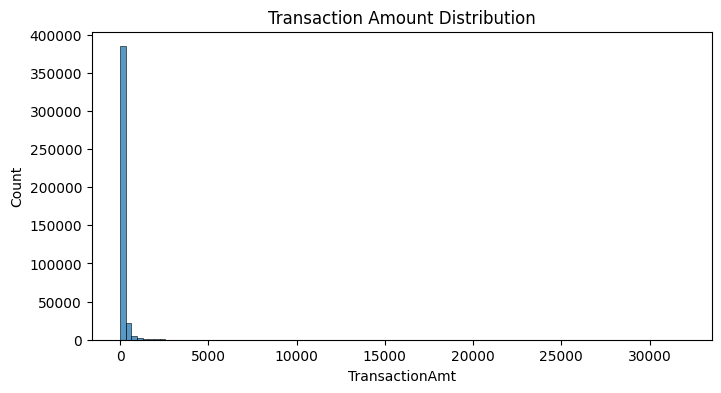

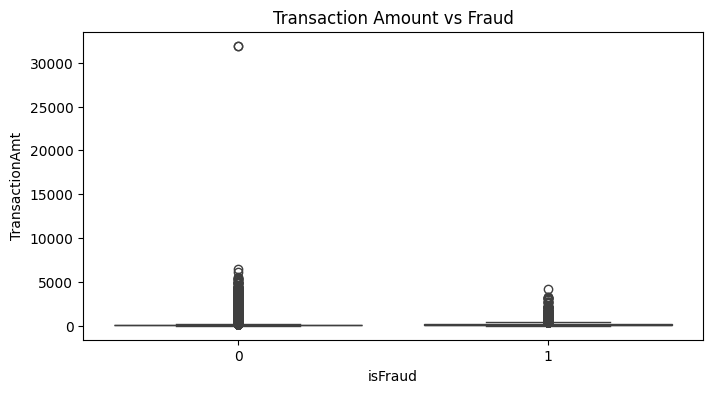

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(df_train['TransactionAmt'], bins=100)
plt.title('Transaction Amount Distribution')
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x='isFraud', y='TransactionAmt', data=df_train)
plt.title('Transaction Amount vs Fraud')
plt.show()

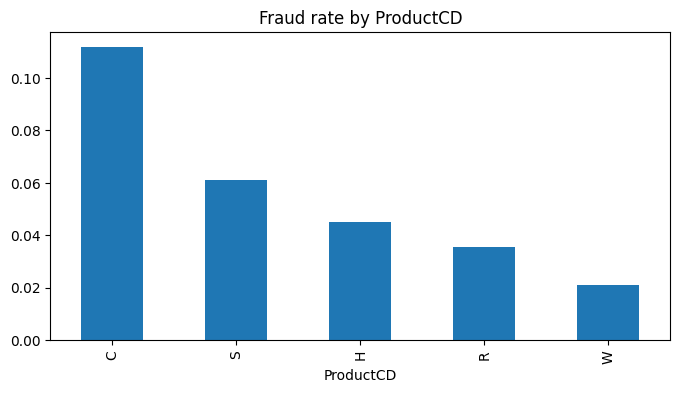

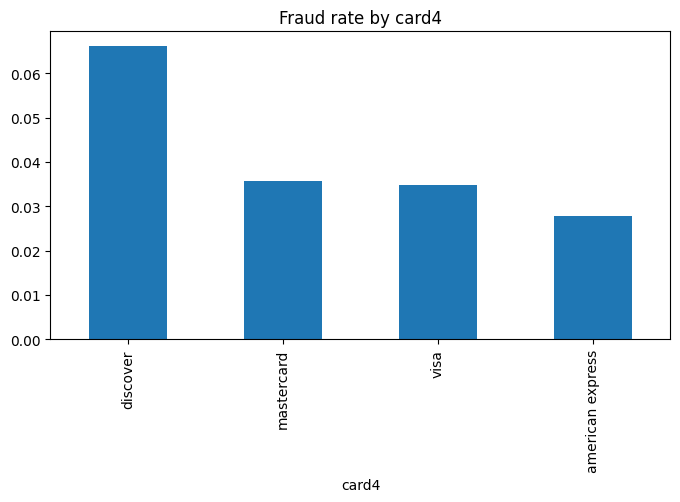

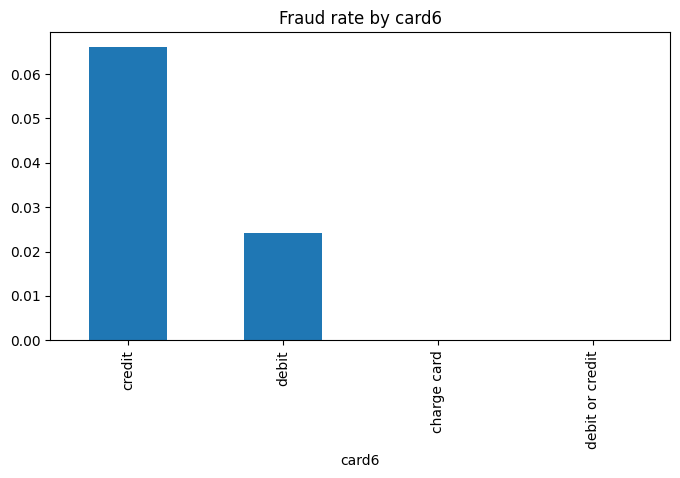

In [11]:
for col in ['ProductCD', 'card4', 'card6']:
    plt.figure(figsize=(8,4))
    fraud_rate = df_train.groupby(col)['isFraud'].mean().sort_values(ascending=False)
    fraud_rate.plot(kind='bar')
    plt.title(f'Fraud rate by {col}')
    plt.show()

Распределение суммы транзакций сильно скошено вправо: большинство операций — на небольшие суммы, но есть редкие очень крупные значения (выбросы). Это может влиять на модель, поэтому возможно стоит применить логарифмирование или ограничение выбросов.

По boxplot видно, что у мошеннических транзакций распределение суммы немного отличается, но сильного разделения нет — значит, один этот признак не даёт хорошего сигнала.

Категориальные признаки показывают более заметную связь с таргетом. Например, по ProductCD видно, что разные категории продуктов имеют сильно разный уровень fraud, особенно выделяется категория C. Аналогично по card4 и card6 — для некоторых типов карт доля мошенничества выше, чем для других.

В целом можно сделать вывод, что категориальные признаки дают более сильный сигнал, чем отдельные числовые признаки, и их обязательно нужно учитывать в модели.

In [12]:
corr = df_train[num_cols].corrwith(df_train['isFraud']).sort_values(key=np.abs, ascending=False)

print('Top correlated features:')
print(corr.head(20))

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Top correlated features:
V257    0.270317
V201    0.261781
V200    0.252972
V246    0.251892
V244    0.234577
V233    0.233934
V189    0.231900
V242    0.229355
V188    0.223533
V171    0.222353
V217    0.220342
V258    0.218448
V232    0.218144
V231    0.217720
V170    0.210237
V228    0.206757
V52     0.190984
V199    0.188536
V219    0.187764
V45     0.180732
dtype: float64


In [13]:
weak_features = corr[np.abs(corr) < 0.01].index.tolist()
print('Weak features (<0.01):', len(weak_features))

Weak features (<0.01): 43


In [14]:
df_train = df_train.drop_duplicates().reset_index(drop=True)

df_train = df_train.drop(columns=weak_features)
df_test = df_test.drop(columns=weak_features)

print('After dropping weak features:')
print(df_train.shape, df_test.shape)

After dropping weak features:
(417285, 389) (172981, 388)


In [15]:
for col in cat_cols:
    df_train[col] = df_train[col].astype('category')
    df_test[col] = df_test[col].astype('category')

В ходе EDA я посмотрел на распределение признаков и их связь с таргетом. Видно, что классы сильно несбалансированы - мошенничество встречается редко, это нужно учитывать при обучении моделей. Также в данных много пропусков, особенно в части признаков из identity.

Числовые признаки в целом слабо связаны с таргетом, но есть отдельные признаки (в основном из группы V), которые показывают заметную корреляцию и могут быть полезны. При этом часть признаков почти не связана с таргетом, поэтому я удалил около 40 таких колонок.

Категориальные признаки, наоборот, дают более явный сигнал, поэтому их важно учитывать.

Также я удалил дубликаты и привел типы данных, чтобы дальше было удобнее обучать модель.

В целом данные не идеальные, но в них есть сигнал, на котором можно строить модель.

# **Задание 2 (3 балла)**

Обучите несколько ML-моделей для решения поставленной задачи.
Оцените их качество двумя способами:

1) на кросс-валидации

2) на лидерборде

Подберите число фолдов на кросс-валидации так, чтобы метрики, которые вы видите, были максимально близки на кросс-валидации и на лидерборде.

По результатам экспериментов постройте таблицу:
* в каждой строке таблицы - результаты одной модели
* по столбцам: качество на кросс-валидации, качество на лидерборде, модель с гиперпараметрами
Полученную таблицу вставьте картинкой прямо в ноутбук после ячеек с кодом. Сделайте текстовые выводы.

### **За что могут быть снижены баллы:**

1. Вы выбираете модели и не обосновываете почему выбрали такие.
2. Вы перебираете гиперпараметры и не обосновываете, почему перебираете именно их.
3. Нет summary по всем исследованным моделям и их качеству.

Для решения задачи были выбраны две модели: логистическая регрессия и CatBoost.

Логистическая регрессия используется как базовая модель. Она простая, быстрая и позволяет получить понятный baseline, с которым удобно сравнивать более сложные методы.

CatBoost был выбран как основная модель, так как он хорошо работает с табличными данными, умеет учитывать категориальные признаки без сложной дополнительной обработки и часто показывает сильный результат в задачах fraud detection.

Для логистической регрессии использовалась стандартная нормализация признаков. Для CatBoost были выбраны базовые гиперпараметры iterations, depth и learning_rate, так как именно они сильнее всего влияют на качество модели и позволяют получить хороший baseline без слишком долгого подбора.

In [16]:
X_num = df_train.select_dtypes(exclude=['object', 'category']).drop(columns=['isFraud'])
y = df_train['isFraud']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])

scores = cross_val_score(
    model,
    X_num,
    y,
    cv=cv,
    scoring='roc_auc'
)

print('LR CV scores:', scores)
print('Mean:', scores.mean())

LR CV scores: [0.84292614 0.83725007 0.84258389 0.83735784 0.8380515 ]
Mean: 0.8396338890594635


Логистическая регрессия показала средний ROC-AUC около 0.84 на кросс-валидации. Это неплохой baseline для простой линейной модели, но он ограничен тем, что модель учитывает только числовые признаки и не умеет хорошо ловить сложные нелинейные зависимости.

In [18]:
X_train_full = df_train.drop(columns=['isFraud']).copy()
y_train_full = df_train['isFraud'].copy()
X_test_full = df_test.copy()

num_features = X_train_full.select_dtypes(exclude=['object', 'category']).columns.tolist()

X_train_lr = X_train_full[num_features].copy()
X_test_lr = X_test_full[num_features].copy()

lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])

lr_model.fit(X_train_lr, y_train_full)

lr_test_pred = lr_model.predict_proba(X_test_lr)[:, 1]

lr_submission = pd.read_csv('sample_submission.csv')
lr_submission['isFraud'] = lr_test_pred
lr_submission.to_csv('submission_lr.csv', index=False)

lr_submission.head()

,TransactionID,isFraud
0,3404559,0.000237
1,3404560,0.008071
2,3404561,0.001192
3,3404562,0.000383
4,3404563,0.009988


Логистическая регрессия показала ROC-AUC около 0.84 на кросс-валидации и около 0.80 на лидерборде. Видно, что качество на кросс-валидации немного выше, чем на тесте, что может говорить о небольшом переобучении или различии распределений данных.

In [17]:
X = df_train.drop(columns=['isFraud']).copy()
y = df_train['isFraud'].copy()

cat_features = X.select_dtypes(include=['category', 'object']).columns.tolist()

for col in cat_features:
    X[col] = X[col].astype(str).fillna('missing')

cat_feature_indices = [X.columns.get_loc(col) for col in cat_features]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    eval_metric='AUC',
    random_state=42,
    verbose=0
)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring='roc_auc',
    params={'cat_features': cat_feature_indices}
)

print('CatBoost CV scores:', cv_scores)
print('Mean:', np.mean(cv_scores))

CatBoost CV scores: [0.90290484 0.89883111 0.90252331]
Mean: 0.9014197514413554


CatBoost показал средний ROC-AUC около 0.90 на кросс-валидации, что заметно лучше результата логистической регрессии. Это ожидаемо, так как CatBoost умеет работать с категориальными признаками и лучше моделирует сложные зависимости между признаками.

Для CatBoost было выбрано 3 фолда, так как эта модель обучается заметно дольше, а оценка при таком числе фолдов остаётся стабильной и позволяет сравнивать качество с лидербордом без слишком долгого пересчёта.

In [19]:
X = df_train.drop(columns=['isFraud']).copy()
y = df_train['isFraud'].copy()
X_test = df_test.copy()

cat_features = X.select_dtypes(include=['category', 'object']).columns.tolist()

for col in cat_features:
    X[col] = X[col].astype(str).fillna('missing')
    X_test[col] = X_test[col].astype(str).fillna('missing')

cat_feature_indices = [X.columns.get_loc(col) for col in cat_features]

model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    eval_metric='AUC',
    random_state=42,
    verbose=0
)

model.fit(X, y, cat_features=cat_feature_indices)

test_pred = model.predict_proba(X_test)[:, 1]

submission = pd.read_csv('sample_submission.csv')
submission['isFraud'] = test_pred
submission.to_csv('submission_catboost.csv', index=False)

submission.head()

,TransactionID,isFraud
0,3404559,0.004289
1,3404560,0.118130
2,3404561,0.020330
3,3404562,0.020657
4,3404563,0.130216


Результат на лидерборде:

Public Score: 0.86996

Private Score: 0.86350

CatBoost показал заметно лучший результат, чем логистическая регрессия, как на кросс-валидации, так и на лидерборде.

In [20]:
results_table = pd.DataFrame({
    'Model': [
        'LogisticRegression (max_iter=1000, StandardScaler, 5 folds)',
        'CatBoost (iterations=300, depth=6, learning_rate=0.1, 3 folds)'
    ],
    'CV ROC-AUC': [
        0.8396338890594635,
        0.9014197514413554
    ],
    'Leaderboard Public': [
        0.80541,
        0.86996
    ],
    'Leaderboard Private': [
        0.79479,
        0.86350
    ]
})

results_table

,Model,CV ROC-AUC,Leaderboard Public,Leaderboard Private
0,"LogisticRegression (max_iter=1000, StandardSca...",0.839634,0.80541,0.79479
1,"CatBoost (iterations=300, depth=6, learning_ra...",0.901420,0.86996,0.86350


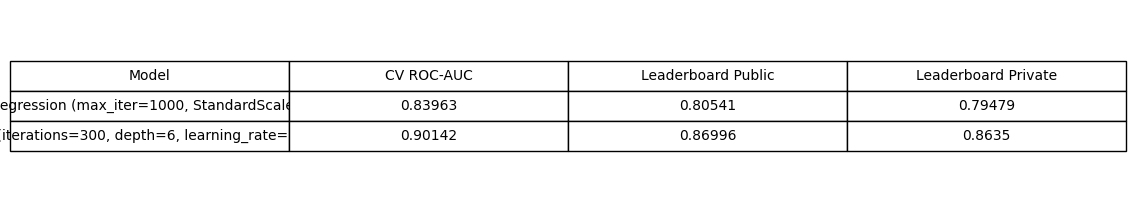

In [21]:
fig, ax = plt.subplots(figsize=(12, 2.5))
ax.axis('off')

tbl = ax.table(
    cellText=results_table.round(5).values,
    colLabels=results_table.columns,
    cellLoc='center',
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)

# plt.savefig('results_table.png', bbox_inches='tight', dpi=200)
plt.show()

В ходе экспериментов были обучены две модели: логистическая регрессия и CatBoost. Логистическая регрессия использовалась как простой baseline, а CatBoost — как более сильная модель для табличных данных с категориальными признаками.

По результатам экспериментов CatBoost показал заметно лучшее качество, чем логистическая регрессия. Средний ROC-AUC на кросс-валидации у него составил около 0.90, тогда как у логистической регрессии — около 0.84. На лидерборде CatBoost также оказался лучше: 0.86996 против 0.80541 по public score.

В обоих случаях качество на кросс-валидации оказалось немного выше, чем на лидерборде, то есть локальная оценка немного оптимистична. Тем не менее разрыв остаётся умеренным, особенно для CatBoost, поэтому такую валидацию можно считать достаточно полезной для сравнения моделей.

Таким образом, лучшей моделью среди рассмотренных оказался CatBoost, и именно его имеет смысл использовать дальше как основную модель для решения задачи.

# **Задание 3 (2 балла)**

Попробуйте подойти к задаче как к поиску аномалий.

1) Поищите аномалии (фрод) различными рассмотренными в курсе методами и сделайте прогноз на тестовых данных.

Результатом также будет таблица:
* по строкам - методы поиска аномалий
* по столбцам - качество вашего решения на leaderboard

2) Попробуйте встроить поиск аномалий и их удаление в ML-пайплайн: найдите аномалии и что-нибудь с ними сделайте до обучения моделей (можно удалить их, а можно использовать в качестве дополнительных признаков - попробуйте разные стратегии). Результат проверьте на кросс-валидации и на лидерборде, сделайте выводы.

### **За что могут быть снижены баллы:**

1. Вы выбираете модели и не обосновываете почему выбрали такие.
2. Вы перебираете стратегии, но не анализируете как сработала или не сработала каждая.
3. Нет summary по исследованию аномалий в контексте этой задачи.

In [25]:
X_num = df_train.select_dtypes(exclude=['object', 'category']).drop(columns=['isFraud']).copy()
y = df_train['isFraud'].copy()

X_test_num = df_test.select_dtypes(exclude=['object', 'category']).copy()

print(X_num.shape, X_test_num.shape)

X_train_anom, X_valid_anom, y_train_anom, y_valid_anom = train_test_split(
    X_num, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_anom_scaled = scaler.fit_transform(X_train_anom)
X_valid_anom_scaled = scaler.transform(X_valid_anom)
X_test_anom_scaled = scaler.transform(X_test_num)

print(X_train_anom_scaled.shape, X_valid_anom_scaled.shape)

(417285, 357) (172981, 357)
(333828, 357) (83457, 357)


In [27]:
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_train_anom_scaled)

train_scores = iso_model.decision_function(X_valid_anom_scaled)

train_scores = -train_scores

auc = roc_auc_score(y_valid_anom, train_scores)
print("IsolationForest ROC-AUC (valid):", auc)

IsolationForest ROC-AUC (valid): 0.7657234178088441


In [28]:
test_scores = iso_model.decision_function(X_test_anom_scaled)
test_scores = -test_scores

iso_submission = pd.read_csv('sample_submission.csv')
iso_submission['isFraud'] = test_scores

iso_submission.to_csv('submission_isolation_forest.csv', index=False)

iso_submission.head()

,TransactionID,isFraud
0,3404559,-0.145446
1,3404560,-0.041833
2,3404561,-0.174063
3,3404562,-0.159038
4,3404563,-0.084813


In [29]:
iso_model_full = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

iso_model_full.fit(X_num)

train_anomaly = -iso_model_full.decision_function(X_num)
test_anomaly = -iso_model_full.decision_function(X_test_num)

df_train['anomaly_score'] = train_anomaly
df_test['anomaly_score'] = test_anomaly

print(df_train['anomaly_score'].describe())

count    417285.000000
mean         -0.136282
std           0.061777
min          -0.188941
25%          -0.179165
50%          -0.163247
75%          -0.113684
max           0.250288
Name: anomaly_score, dtype: float64


/tmp/ipykernel_23929/2175665903.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test['anomaly_score'] = test_anomaly


In [31]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from catboost import CatBoostClassifier
import numpy as np

X_anom = df_train.drop(columns=['isFraud']).copy()
y = df_train['isFraud'].copy()

cat_features_anom = X_anom.select_dtypes(include=['category', 'object']).columns.tolist()

for col in cat_features_anom:
    X_anom[col] = X_anom[col].astype(str).fillna('missing')

cat_feature_indices_anom = [X_anom.columns.get_loc(col) for col in cat_features_anom]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    eval_metric='AUC',
    random_state=42,
    verbose=0
)

cv_scores_anom = cross_val_score(
    model,
    X_anom,
    y,
    cv=cv,
    scoring='roc_auc',
    params={'cat_features': cat_feature_indices_anom}
)

print('CatBoost + anomaly_score CV scores:', cv_scores_anom)
print('Mean:', np.mean(cv_scores_anom))

CatBoost + anomaly_score CV scores: [0.90256247 0.90019343 0.90182154]
Mean: 0.9015258137361117


In [30]:
X = df_train.drop(columns=['isFraud']).copy()
y = df_train['isFraud'].copy()
X_test = df_test.copy()

cat_features = X.select_dtypes(include=['category', 'object']).columns.tolist()

for col in cat_features:
    X[col] = X[col].astype(str).fillna('missing')
    X_test[col] = X_test[col].astype(str).fillna('missing')

cat_feature_indices = [X.columns.get_loc(col) for col in cat_features]

model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    eval_metric='AUC',
    random_state=42,
    verbose=0
)

model.fit(X, y, cat_features=cat_feature_indices)

test_pred = model.predict_proba(X_test)[:, 1]

submission = pd.read_csv('sample_submission.csv')
submission['isFraud'] = test_pred
submission.to_csv('submission_catboost_anomaly.csv', index=False)

submission.head()

,TransactionID,isFraud
0,3404559,0.003611
1,3404560,0.047954
2,3404561,0.015531
3,3404562,0.011413
4,3404563,0.126525


Попробовал добавить anomaly score, полученный с помощью IsolationForest, в качестве дополнительного признака.

На кросс-валидации качество практически не изменилось (ROC-AUC остался около 0.90), что говорит о том, что модель и без этого признака уже хорошо улавливает основные закономерности в данных.

Однако на лидерборде наблюдается небольшой рост качества (с 0.8699 до 0.8713), что может означать, что anomaly score добавляет дополнительную информацию, полезную для обобщения на тестовых данных.

В целом можно сказать, что добавление anomaly score как признака даёт небольшой, но стабильный прирост качества.

In [32]:
threshold = np.percentile(df_train['anomaly_score'], 95)

df_train_filtered = df_train[df_train['anomaly_score'] < threshold].copy()

print("Original shape:", df_train.shape)
print("Filtered shape:", df_train_filtered.shape)

Original shape: (417285, 390)
Filtered shape: (396420, 390)


In [33]:
X = df_train_filtered.drop(columns=['isFraud']).copy()
y = df_train_filtered['isFraud'].copy()
X_test = df_test.copy()

cat_features = X.select_dtypes(include=['category', 'object']).columns.tolist()

for col in cat_features:
    X[col] = X[col].astype(str).fillna('missing')
    X_test[col] = X_test[col].astype(str).fillna('missing')

cat_feature_indices = [X.columns.get_loc(col) for col in cat_features]

model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    eval_metric='AUC',
    random_state=42,
    verbose=0
)

model.fit(X, y, cat_features=cat_feature_indices)

test_pred = model.predict_proba(X_test)[:, 1]

submission = pd.read_csv('sample_submission.csv')
submission['isFraud'] = test_pred
submission.to_csv('submission_catboost_filtered.csv', index=False)

submission.head()

,TransactionID,isFraud
0,3404559,0.004888
1,3404560,0.161038
2,3404561,0.019205
3,3404562,0.021191
4,3404563,0.142694


In [34]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_scores_filtered = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring='roc_auc',
    params={'cat_features': cat_feature_indices}
)

print('CatBoost (filtered) CV scores:', cv_scores_filtered)
print('Mean:', np.mean(cv_scores_filtered))

CatBoost (filtered) CV scores: [0.8637585  0.86484628 0.85956956]
Mean: 0.8627247796929683


Попробовал удалить самые аномальные объекты (топ 5% по anomaly score) из обучающей выборки перед обучением модели.

На кросс-валидации качество заметно ухудшилось (ROC-AUC снизился с ~0.90 до ~0.86), что говорит о том, что среди аномалий содержится важная информация для предсказания фрода.

При этом на лидерборде наблюдается небольшой рост качества по сравнению с базовой моделью, однако он не сопровождается улучшением на валидации, что может говорить о нестабильности такого подхода.

Таким образом, удаление аномалий не является хорошей стратегией для данной задачи, так как приводит к потере полезной информации.

In [36]:
strategy_results = pd.DataFrame({
    'Strategy': [
        'CatBoost (baseline)',
        'CatBoost + anomaly_score',
        'CatBoost (remove anomalies)'
    ],
    'CV ROC-AUC': [
        0.9014,
        0.9015,
        0.8627
    ],
    'Leaderboard Public': [
        0.86996,
        0.87133,
        0.87164
    ],
    'Leaderboard Private': [
        0.86350,
        0.86634,
        0.86526
    ]
})

strategy_results

,Strategy,CV ROC-AUC,Leaderboard Public,Leaderboard Private
0,CatBoost (baseline),0.9014,0.86996,0.86350
1,CatBoost + anomaly_score,0.9015,0.87133,0.86634
2,CatBoost (remove anomalies),0.8627,0.87164,0.86526


Пробовал рассматривать задачу как задачу поиска аномалий. Для этого был использован метод IsolationForest, который показал ROC-AUC около 0.78 на лидерборде. Это хуже, чем у обучаемых моделей, но при этом результат оказался достаточно высоким для метода, не использующего таргет.

Далее были рассмотрены различные способы использования аномалий в модели. Добавление anomaly score как дополнительного признака дало небольшой прирост качества на лидерборде при сохранении стабильного качества на кросс-валидации. Это говорит о том, что информация об аномальности действительно полезна для модели.

Также была протестирована стратегия удаления аномалий из обучающей выборки. Несмотря на небольшой рост качества на лидерборде, качество на кросс-валидации значительно ухудшилось, что указывает на потерю полезной информации.

Таким образом, лучший результат показала стратегия использования anomaly score как дополнительного признака, тогда как удаление аномалий оказалось неэффективным.

# **Задание 4 (1 балл)**

Сделайте кластеризацию различными способами. Результаты кластеризации используйте для улучшения ML-решений:

1) Номера кластеров закодируйте (OHE или target-encoding) и добавьте как новые признаки

2) При использовании DBSCAN / HDBSCAN предсказанный шум можно трактовать как найденную аномалию и также добавить ее как новый признак

Проведите различные эксперименты. Проверьте как эти подходы влияют на качество прогнозов по кросс-валидации и на лидерборде, сделайте выводы.

### **За что могут быть снижены баллы:**

1. Нет summary по исследованию аномалий в контексте этой задачи.

In [ ]:
# ваши эксперименты с кластеризацией здесь

## **Задание 5 (1 балл)**

Примените какой-нибудь (один любой) AutoML фреймворк для решения поставленной задачи.

Отправьте AutoML-прогноз на kaggle и посмотрите на качество модели. Сделайте текстовые выводы.

### **За что могут быть снижены баллы:**

1. Нет текстового вывода.
2. Качество кода.  

In [ ]:
# ваш AutoML здесь

# **Задание 6 (1 балл)**

Весь курс мы работали в Google Colab. Но всегда должны быть запасные варианты, где Вы будете обучать модели.

Среди вариантов есть:
* ваша локальная машина
* kaggle notebooks
* yandex cloud
и другие.

Кроме привычного Google Colab выберите из списка выше один любой альтернативный вариант и проведите эксперимент:

* Прогоните ваш лучший по качеству по результатам заданий 2-4 ML-пайплайн заново в Google Colab и с помощью библиотек (например, при помощи библиотеки time) замерьте время обучения и отдельно время инференса на тестовых данных

* Прогоните этот пайплайн на выбранном альтернативном сервисе/локальной машине и также замерьте время обучения и инференса.

Текстом напишите выводы: опишите, какое альтернативное место для обучения моделей Вы использовали? Прикрепите прямо в ноутбук скриншот с экраном кода в альтернативном сервисе/на локальной машине. Также в виде таблицы приведите сравнение времени обучения и инференса в колабе и в альтернативном месте. Сделайте выводы.

### **За что могут быть снижены баллы:**

1. Нет текстового вывода.
2. Качество кода.  

In [ ]:
# ваши эксперименты здесь

# **Бонус: за Kaggle и стремление к хорошим скорам (2 балла)**

В этом домашнем задании Ваша цель - не просто выполнить шаги выше, но и построить максимально хорошую по качеству модель.

**К 10 вы можете получить до двух дополнительных баллов:**

* За попадание в топ-20% на private leaderboard — +1 дополнительный балл к оценке
* За попадание в топ-5 мест на private leaderboard — + еще один дополнительный балл к оценке (то есть суммарно 2 дополнительных балла)

**ВАЖНО!!!**

Эти баллы ставятся до мягкого дедлайна по соревнованию. После мягкого дедлайна лидерборд не обновляется, и дополнительные баллы не ставятся.

Успехов!

In [ ]:
# не забудьте прикрепить скриншоты лидерборда, пожалуйста